# Import

In [1]:
import numpy as np
import pandas as pd
import json
import gc
import re
import os
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import random
import torch


In [2]:
transaction_df = pd.read_csv("transactions_data_south_africa.csv")
card_df = pd.read_csv("cards_data_south_africa (1).csv")
users_df = pd.read_csv("user_data_south_africa.csv")
train_fraud_labels = pd.read_csv("train_fraud_labels.csv")
mcc_df = pd.read_json("mcc_codes (2).json" , orient="index")



In [3]:
mcc_df = mcc_df.reset_index()
mcc_df.columns = ['mcc', 'description']

In [4]:
mcc_df

,mcc,description
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees
...,...,...
104,7549,Towing Services
105,5941,Sporting Goods Stores
106,5722,Household Appliance Stores
107,3009,Fabricated Structural Metal Products


In [4]:
data_dict = {'transaction': transaction_df,
             'card': card_df,
             'user': users_df,
             'mcc': mcc_df,
             'fraud_labels': train_fraud_labels
            } 
print("\nSuccessfuly save all dataframe in a dictionary called data_dict")


Successfuly save all dataframe in a dictionary called data_dict


In [37]:
data_dict['user']


,id,current_age,retirement_age,birth_year,birth_month,gender,address,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,"126 Main Road, Durban",527004,1074528,2297034,787,5
1,1746,53,68,1966,12,Female,"254 Van der Merwe Avenue, Cape Town",682038,1390572,3444282,701,5
2,1718,81,67,1938,11,Female,"856 King George Street, Pietermaritzburg",408258,602694,3528,698,5
3,708,63,63,1957,1,Female,"565 Pretoria Street, Durban",2936610,4498650,3641904,722,4
4,1164,43,70,1976,9,Male,"269 Swart Street, Pretoria",968346,1974366,3309390,675,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,986,32,70,1987,7,Male,"83 Cape Road, Johannesburg",423900,864180,1581066,703,3
1996,1944,62,65,1957,11,Female,"372 Durban Road, Durban",435924,888804,1880640,740,4
1997,185,47,67,1973,1,Female,"303 Queen Street, Bloemfontein",273150,556956,1279188,779,3
1998,1007,66,60,1954,2,Male,"81 Van der Merwe Avenue, East London",456048,983772,490338,618,1


# Cleaning

In [5]:
# ====================
# Basic prprosessing
# ====================

def cleaned_transaction(df):
    df = df.copy()

    df['date'] = pd.to_datetime(df['date']) # conviert to datetime
    df['errors'] = df['errors'].fillna('no error') # fill nulls
    df['merchant_state'] = np.where(df['merchant_city'] == 'ONLINE', 'ONLINE', df['merchant_state']) # check if city is online and fill state
    df['zip'] = df['zip'] = np.where(df['merchant_city'] == 'ONLINE', 0, df['zip']) # fill zip if city == 'Online' or keep original if false
    df['mcc'] = df['mcc'].fillna(5812) # fill nulls
    return df

# conviert to datetime
data_dict['card']['expires'] = pd.to_datetime(data_dict['card']['expires']) 
data_dict['card']['acct_open_date'] = pd.to_datetime(data_dict['card']['acct_open_date'])
data_dict['transaction']["date"] = pd.to_datetime(data_dict['transaction']["date"])

print("\nSuccessfuly preprocessed")


Successfuly preprocessed


In [6]:
transaction_df

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2022-02-19 05:51:55,1556,2972,-1386.00,Swipe Transaction,59935,Kimberley,Northern Cape,8300.0,5499.0,NaN
1,7475328,2023-01-13 02:58:58,561,4575,262.26,Swipe Transaction,67570,Pietermaritzburg,KwaZulu-Natal,3200.0,5311.0,NaN
2,7475329,2024-07-03 23:41:24,1129,102,1440.00,Swipe Transaction,27092,Port Elizabeth,Eastern Cape,6000.0,4829.0,NaN
3,7475331,2022-06-12 09:33:41,430,2860,3600.00,Swipe Transaction,27092,Bloemfontein,Free State,9300.0,4829.0,NaN
4,7475332,2023-08-26 10:05:48,848,3915,835.38,Swipe Transaction,13051,Polokwane,Limpopo,700.0,5813.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
12858749,23209463,2022-05-16 02:17:24,597,4540,126.00,Online Transaction,51397,ONLINE,NaN,NaN,5651.0,NaN
12858750,23209464,2023-07-23 01:05:29,1508,3279,593.46,Chip Transaction,43293,Cape Town,Western Cape,8000.0,5499.0,NaN
12858751,23209465,2023-05-03 10:17:19,1727,4918,284.04,Online Transaction,18563,ONLINE,NaN,NaN,4121.0,NaN
12858752,23209466,2022-05-15 15:12:30,467,4278,812.88,Chip Transaction,31893,Cape Town,Western Cape,8000.0,5311.0,NaN


Save cleaned data


In [7]:
mcc_cl = data_dict['mcc']
transaction_cl = cleaned_transaction(data_dict['transaction'])
card_cl = data_dict['card'].drop(columns=data_dict['card'][['card_on_dark_web']])
user_cl = data_dict['user']
fraud_labels_cl = data_dict['fraud_labels']
print("\nSuccessfuly saved")


Successfuly saved


In [8]:
transaction_cl.isnull().sum()

id                0
date              0
client_id         0
card_id           0
amount            0
use_chip          0
merchant_id       0
merchant_city     0
merchant_state    0
zip               0
mcc               0
errors            0
dtype: int64

In [9]:
mcc_cl

,mcc,description
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees
...,...,...
104,7549,Towing Services
105,5941,Sporting Goods Stores
106,5722,Household Appliance Stores
107,3009,Fabricated Structural Metal Products


# Merge


In [10]:
def column_name_standardization(transaction, card, mcc, user):
    transaction = transaction.rename(columns={'id':'transaction_id'})
    card = card.rename(columns={'id': 'card_id'})
    mcc = mcc.rename(columns={'mcc_code': 'mcc'})
    user = user.rename(columns={'id': 'client_id'})
    return transaction, card, mcc, user
transaction_cl, card_cl, mcc_cl, user_cl = column_name_standardization(transaction_cl, card_cl, mcc_cl, user_cl)

In [11]:
df_merge = transaction_cl.copy()
df_merge = df_merge.merge(card_cl, how='left', on=['card_id','client_id'])
df_merge = df_merge.merge(mcc_cl, how='left', on=['mcc'])
df_merge = df_merge.merge(user_cl, how='left', on=['client_id'])
df_merge = df_merge.merge(fraud_labels_cl, how='left', on=['transaction_id'])

In [12]:
df_merge

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,birth_year,birth_month,gender,address,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,is_fraud
0,7475327,2022-02-19 05:51:55,1556,2972,-1386.00,Swipe Transaction,59935,Kimberley,Northern Cape,8300.0,...,1989,7,Female,"405 Pretoria Street, Johannesburg",426222,868986,1982754,740,4,No
1,7475328,2023-01-13 02:58:58,561,4575,262.26,Swipe Transaction,67570,Pietermaritzburg,KwaZulu-Natal,3200.0,...,1971,6,Male,"374 Voortrekker Road, Bloemfontein",325368,663354,2018502,834,5,No
2,7475329,2024-07-03 23:41:24,1129,102,1440.00,Swipe Transaction,27092,Port Elizabeth,Eastern Cape,6000.0,...,1970,4,Male,"146 Voortrekker Road, Gqeberha",304092,620082,657720,686,3,No
3,7475331,2022-06-12 09:33:41,430,2860,3600.00,Swipe Transaction,27092,Bloemfontein,Free State,9300.0,...,1967,5,Female,"573 Durban Road, East London",471024,960300,2316168,685,5,NaN
4,7475332,2023-08-26 10:05:48,848,3915,835.38,Swipe Transaction,13051,Polokwane,Limpopo,700.0,...,1968,5,Male,"944 Church Street, East London",603522,1230516,1731276,711,2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858749,23209463,2022-05-16 02:17:24,597,4540,126.00,Online Transaction,51397,ONLINE,ONLINE,0.0,...,1948,1,Male,"499 Church Street, Gqeberha",930456,1170990,30168,736,6,No
12858750,23209464,2023-07-23 01:05:29,1508,3279,593.46,Chip Transaction,43293,Cape Town,Western Cape,8000.0,...,1953,4,Female,"495 Durban Road, Cape Town",344250,701982,1167750,747,4,NaN
12858751,23209465,2023-05-03 10:17:19,1727,4918,284.04,Online Transaction,18563,ONLINE,ONLINE,0.0,...,1973,10,Female,"323 Main Road, East London",430506,877716,2577744,771,6,No
12858752,23209466,2022-05-15 15:12:30,467,4278,812.88,Chip Transaction,31893,Cape Town,Western Cape,8000.0,...,1981,9,Male,"280 Victoria Road, Pretoria",395784,806958,376308,705,3,NaN


In [13]:
df = df_merge.copy()

# Feature engineering

In [14]:
# Is_fraud to binary
df['target'] = df['is_fraud'].map({'Yes': 1, 'No': 0})


FULL FRAUD FEATURE ENGINEERING PIPELINE (PRODUCTION SAFE)


In [15]:
# -----------------------------------------------------
# TIME FEATURES
# -----------------------------------------------------
def time_features(df):
    df = df.copy()
    # Sort
    df = df.sort_values(["client_id", "date"]).reset_index(drop=True)

    df["hour"] = df["date"].dt.hour.astype("int32")
    df["dayofweek"] = df["date"].dt.dayofweek.astype("int32")
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype("int32")
    df["is_night"] = df["hour"].between(0, 5).astype("int32")
    df["is_month_end"] = df["date"].dt.is_month_end.astype("int32")
    return df
fe = time_features(df)

In [46]:
fe

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,total_debt,credit_score,num_credit_cards,is_fraud,target,hour,dayofweek,is_weekend,is_night,is_month_end
0,8927991,2022-01-01 00:46:02,0,4639,179.28,Swipe Transaction,55060,Polokwane,Limpopo,700.0,...,651582,763,4,No,0.0,0,5,1,1,0
1,20704571,2022-01-01 05:02:57,0,1271,5724.00,Chip Transaction,3558,Cape Town,Western Cape,8000.0,...,651582,763,4,No,0.0,5,5,1,1,0
2,18886224,2022-01-01 06:04:41,0,1271,987.12,Chip Transaction,32164,Cape Town,Western Cape,8000.0,...,651582,763,4,No,0.0,6,5,1,0,0
3,17146921,2022-01-01 07:26:03,0,4639,1003.86,Chip Transaction,26593,Kimberley,Northern Cape,8300.0,...,651582,763,4,NaN,NaN,7,5,1,0,0
4,10496251,2022-01-01 07:49:43,0,4639,279.18,Swipe Transaction,60510,Durban,KwaZulu-Natal,4000.0,...,651582,763,4,No,0.0,7,5,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858749,13254825,2024-12-28 08:20:17,1998,2160,61.56,Swipe Transaction,27715,Bloemfontein,Free State,9300.0,...,14220,688,3,No,0.0,8,5,1,0,0
12858750,21588267,2024-12-28 10:31:43,1998,2160,185.76,Swipe Transaction,45756,Pietermaritzburg,KwaZulu-Natal,3200.0,...,14220,688,3,No,0.0,10,5,1,0,0
12858751,10035325,2024-12-28 13:33:34,1998,2160,183.24,Swipe Transaction,13646,East London,Eastern Cape,5200.0,...,14220,688,3,No,0.0,13,5,1,0,0
12858752,10404322,2024-12-28 14:43:12,1998,1258,150.48,Swipe Transaction,46284,Bloemfontein,Free State,9300.0,...,14220,688,3,No,0.0,14,5,1,0,0


In [18]:
def transaction_features(df):
    df = df.copy()
    # Sort
    df = df.sort_values(["date"]).reset_index(drop=True)

        # Log amount features
    df["abs_amount"] = df["amount"].abs().astype("float32").fillna(0)
    df["log_amount"] = np.log1p(df["abs_amount"]).astype("float32").fillna(0)
    df["amount_sign"] = np.sign(df["amount"]).astype("int8").fillna(0)
    
    # Set date as index temporarily
    df_temp = df.set_index("date")

    # Transactions last 24h
    rolling_24h = (
        df_temp.groupby("client_id")["abs_amount"]
               .rolling("1D", closed="left")
               .count()
    )
    df["txn_last_24h"] = (
        rolling_24h.reset_index(level=0, drop=True)
                   .astype("float32")
                   .fillna(0)
                   .values
    )
    return df

fe = transaction_features(fe)

In [48]:
fe

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,num_credit_cards,is_fraud,target,hour,dayofweek,is_weekend,is_night,is_month_end,txn_last_24h,hours_since_last_txn
0,8927991,2022-01-01 00:46:02,0,4639,179.28,Swipe Transaction,55060,Polokwane,Limpopo,700.0,...,4,No,0.0,0,5,1,1,0,0.0,0.000000
1,20704571,2022-01-01 05:02:57,0,1271,5724.00,Chip Transaction,3558,Cape Town,Western Cape,8000.0,...,4,No,0.0,5,5,1,1,0,1.0,4.281944
2,18886224,2022-01-01 06:04:41,0,1271,987.12,Chip Transaction,32164,Cape Town,Western Cape,8000.0,...,4,No,0.0,6,5,1,0,0,2.0,1.028889
3,17146921,2022-01-01 07:26:03,0,4639,1003.86,Chip Transaction,26593,Kimberley,Northern Cape,8300.0,...,4,NaN,NaN,7,5,1,0,0,3.0,1.356111
4,10496251,2022-01-01 07:49:43,0,4639,279.18,Swipe Transaction,60510,Durban,KwaZulu-Natal,4000.0,...,4,No,0.0,7,5,1,0,0,4.0,0.394444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858749,13254825,2024-12-28 08:20:17,1998,2160,61.56,Swipe Transaction,27715,Bloemfontein,Free State,9300.0,...,3,No,0.0,8,5,1,0,0,3.0,10.839444
12858750,21588267,2024-12-28 10:31:43,1998,2160,185.76,Swipe Transaction,45756,Pietermaritzburg,KwaZulu-Natal,3200.0,...,3,No,0.0,10,5,1,0,0,4.0,2.190556
12858751,10035325,2024-12-28 13:33:34,1998,2160,183.24,Swipe Transaction,13646,East London,Eastern Cape,5200.0,...,3,No,0.0,13,5,1,0,0,5.0,3.030833
12858752,10404322,2024-12-28 14:43:12,1998,1258,150.48,Swipe Transaction,46284,Bloemfontein,Free State,9300.0,...,3,No,0.0,14,5,1,0,0,6.0,1.160556


In [26]:
def behavioral_features(df):
    df = df.copy()

    # Ensure chronological order per client
    df = df.sort_values(["date"]).reset_index(drop=True)

    # --- Expanding behavior features ---
    def expanding_mean_shift(x):
        return x.expanding().mean().shift()

    def expanding_std_shift(x):
        return x.expanding().std(ddof=0).shift()

    # Card-level behavior
    df["card_avg_amount"] = (
        df.groupby("card_id")["abs_amount"]
          .transform(expanding_mean_shift)
          .astype("float32")
          .fillna(0)
    )
    df["card_std_amount"] = (
        df.groupby("card_id")["abs_amount"]
          .transform(expanding_std_shift)
          .astype("float32")
          .fillna(0)
    )

    # Client-level behavior
    df["client_avg_amount"] = (
        df.groupby("client_id")["abs_amount"]
          .transform(expanding_mean_shift)
          .astype("float32")
          .fillna(0)
    )

    # Z-score deviation
    df["amount_zscore_card"] = (
        (df["amount"] - df["card_avg_amount"]) /
        (df["card_std_amount"] + 1e-6)
    ).astype("float32").fillna(0)

        # --- Merchant behavior ---
    df["merchant_txn_count"] = df.groupby(["card_id", "merchant_id"]).cumcount().fillna(0)
    df["new_merchant"] = (df["merchant_txn_count"] == 0).astype("int8").fillna(0)


    df["rapid_repeat_merchant"] = (
        (df["merchant_id"] == df.groupby("card_id")["merchant_id"].shift(1)) &
        ((df["date"] - df.groupby("card_id")["date"].shift(1))
         .dt.total_seconds() < 300)
    ).astype("int8").fillna(0)


    # --- Time behavior deviation ---
    df["hour"] = df["date"].dt.hour.fillna(0)
    # --- Account stability ---
    df["account_age_years"] = ((df["date"] - df["acct_open_date"]).dt.days.div(365).astype("float32").fillna(0))
    if "yearly_income" in df.columns:
        df["spend_to_income_ratio"] = (df["amount"] / (df["yearly_income"] + 1e-6)).astype("float32").fillna(0)

    # --- Transaction sequence ---
    df["first_occurrence"] = (~df["card_id"].duplicated()).astype(int)

    return df
fe = behavioral_features(fe)

In [44]:
fe

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,abs_amount,log_amount,amount_sign,merchant_txn_count,new_merchant,rapid_repeat_merchant,account_age_years,spend_to_income_ratio,first_occurrence,generation
0,8360114,2022-01-01 00:00:05,291,169,607.86,Swipe Transaction,32175,East London,Eastern Cape,5200.0,...,607.859985,6.411588,1,0,1,0,14.010959,0.000836,1,Boomers
1,15626211,2022-01-01 00:00:10,24,2827,47.16,Chip Transaction,14528,Polokwane,Limpopo,700.0,...,47.160000,3.874529,1,0,1,0,19.684931,0.000068,1,Boomers
2,15750655,2022-01-01 00:00:21,696,4207,25.56,Swipe Transaction,46284,Bloemfontein,Free State,9300.0,...,25.559999,3.279406,1,0,1,0,14.430137,0.000013,1,Boomers
3,17529598,2022-01-01 00:00:21,1326,5561,123.12,Chip Transaction,94123,East London,Eastern Cape,5200.0,...,123.120003,4.821249,1,0,1,0,12.175343,0.000103,1,Boomers
4,18999635,2022-01-01 00:00:29,1640,4967,527.40,Swipe Transaction,81536,Port Elizabeth,Eastern Cape,6000.0,...,527.400024,6.269854,1,0,1,0,19.265753,0.000838,1,Boomers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858749,17154471,2024-12-28 23:59:33,1871,2430,1089.00,Chip Transaction,41260,Kimberley,Northern Cape,8300.0,...,1089.000000,6.993933,1,8,0,0,22.758904,0.003642,0,Boomers
12858750,9131880,2024-12-28 23:59:33,379,3881,669.42,Swipe Transaction,32175,Durban,KwaZulu-Natal,4000.0,...,669.419983,6.507905,1,29,0,0,15.504109,0.000855,0,Boomers
12858751,14740296,2024-12-28 23:59:44,980,5052,27.00,Swipe Transaction,22204,East London,Eastern Cape,5200.0,...,27.000000,3.332205,1,287,0,0,18.254795,0.000062,0,Boomers
12858752,17911477,2024-12-28 23:59:52,952,2351,128.16,Chip Transaction,85561,Rustenburg,North West,300.0,...,128.160004,4.861052,1,45,0,0,9.835616,0.000056,0,Boomers


In [20]:
def age_features(df):
    # Standard demographic groups
    demographic_bins = {
        'Gen Z': (0, 25),
        'Millennials': (26, 40),
        'Gen X': (41, 56),
        'Boomers': (57, 75),
        'Silent': (76, 200)
    }

    # Create a function to map ages
    def get_generation(age):
        for gen, (low, high) in demographic_bins.items():
            if low <= age <= high:
                return gen
        return 'Unknown'

    df['generation'] = df['retirement_age'].apply(get_generation)
    return df
fe = age_features(fe)

In [52]:
fe

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,abs_amount,log_amount,amount_sign,merchant_txn_count,new_merchant,rapid_repeat_merchant,account_age_years,spend_to_income_ratio,first_occurrence,generation
0,8927991,2022-01-01 00:46:02,0,4639,179.28,Swipe Transaction,55060,Polokwane,Limpopo,700.0,...,179.279999,5.194511,1,0,1,0,14.345205,0.000167,1,Boomers
1,20704571,2022-01-01 05:02:57,0,1271,5724.00,Chip Transaction,3558,Cape Town,Western Cape,8000.0,...,5724.000000,8.652597,1,0,1,0,10.923287,0.005334,1,Boomers
2,18886224,2022-01-01 06:04:41,0,1271,987.12,Chip Transaction,32164,Cape Town,Western Cape,8000.0,...,987.119995,6.895804,1,0,1,0,10.923287,0.000920,0,Boomers
3,17146921,2022-01-01 07:26:03,0,4639,1003.86,Chip Transaction,26593,Kimberley,Northern Cape,8300.0,...,1003.859985,6.912603,1,0,1,0,14.345205,0.000936,0,Boomers
4,10496251,2022-01-01 07:49:43,0,4639,279.18,Swipe Transaction,60510,Durban,KwaZulu-Natal,4000.0,...,279.179993,5.635432,1,0,1,0,14.345205,0.000260,0,Boomers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858749,13254825,2024-12-28 08:20:17,1998,2160,61.56,Swipe Transaction,27715,Bloemfontein,Free State,9300.0,...,61.560001,4.136126,1,87,0,0,17.841095,0.005302,0,Boomers
12858750,21588267,2024-12-28 10:31:43,1998,2160,185.76,Swipe Transaction,45756,Pietermaritzburg,KwaZulu-Natal,3200.0,...,185.759995,5.229825,1,98,0,0,17.841095,0.016000,0,Boomers
12858751,10035325,2024-12-28 13:33:34,1998,2160,183.24,Swipe Transaction,13646,East London,Eastern Cape,5200.0,...,183.240005,5.216239,1,96,0,0,17.841095,0.015783,0,Boomers
12858752,10404322,2024-12-28 14:43:12,1998,1258,150.48,Swipe Transaction,46284,Bloemfontein,Free State,9300.0,...,150.479996,5.020453,1,44,0,0,14.915069,0.012961,0,Boomers


# Modelling

In [21]:
# ===============================
# 1. Imports
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, auc

from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
# =====================
# 2. Data prep
# =====================

selected_features = [
    "amount_zscore_card",
    "abs_amount",
    'client_avg_amount',
    "description",
    "spend_to_income_ratio",
    "new_merchant",
    "zip",
    "mcc",
    "errors",
    'merchant_state',
    'merchant_city',
    'card_brand',
    'card_type',
    'has_chip',
    'current_age',
    "generation",
    "first_occurrence",
    'is_weekend',
    "target",
    "txn_last_24h",
    "account_age_years",
    "use_chip"
]

'''df_ft = [
    "amount",
    "description",
    "zip",
    "mcc",
    "use_chip",
    "errors",
    'merchant_state',
    'merchant_city',
    'card_brand',
    'card_type',
    'has_chip',
    'current_age'
]'''

print("features selected!")

features selected!


In [82]:
df = fe.copy()

In [49]:
df

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,abs_amount,log_amount,amount_sign,merchant_txn_count,new_merchant,rapid_repeat_merchant,account_age_years,spend_to_income_ratio,first_occurrence,generation
0,8360114,2022-01-01 00:00:05,291,169,607.86,Swipe Transaction,32175,East London,Eastern Cape,5200.0,...,607.859985,6.411588,1,0,1,0,14.010959,0.000836,1,Boomers
1,15626211,2022-01-01 00:00:10,24,2827,47.16,Chip Transaction,14528,Polokwane,Limpopo,700.0,...,47.160000,3.874529,1,0,1,0,19.684931,0.000068,1,Boomers
2,15750655,2022-01-01 00:00:21,696,4207,25.56,Swipe Transaction,46284,Bloemfontein,Free State,9300.0,...,25.559999,3.279406,1,0,1,0,14.430137,0.000013,1,Boomers
3,17529598,2022-01-01 00:00:21,1326,5561,123.12,Chip Transaction,94123,East London,Eastern Cape,5200.0,...,123.120003,4.821249,1,0,1,0,12.175343,0.000103,1,Boomers
4,18999635,2022-01-01 00:00:29,1640,4967,527.40,Swipe Transaction,81536,Port Elizabeth,Eastern Cape,6000.0,...,527.400024,6.269854,1,0,1,0,19.265753,0.000838,1,Boomers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858749,17154471,2024-12-28 23:59:33,1871,2430,1089.00,Chip Transaction,41260,Kimberley,Northern Cape,8300.0,...,1089.000000,6.993933,1,8,0,0,22.758904,0.003642,0,Boomers
12858750,9131880,2024-12-28 23:59:33,379,3881,669.42,Swipe Transaction,32175,Durban,KwaZulu-Natal,4000.0,...,669.419983,6.507905,1,29,0,0,15.504109,0.000855,0,Boomers
12858751,14740296,2024-12-28 23:59:44,980,5052,27.00,Swipe Transaction,22204,East London,Eastern Cape,5200.0,...,27.000000,3.332205,1,287,0,0,18.254795,0.000062,0,Boomers
12858752,17911477,2024-12-28 23:59:52,952,2351,128.16,Chip Transaction,85561,Rustenburg,North West,300.0,...,128.160004,4.861052,1,45,0,0,9.835616,0.000056,0,Boomers


In [83]:
df.shape

(12858754, 56)

In [84]:
df_model = df[selected_features]
df_model = df_model[df_model['target'].notnull()]
df_target_null = df_model[df_model['target'].isnull()]

In [52]:
df_model

,amount_zscore_card,abs_amount,amount,client_avg_amount,description,spend_to_income_ratio,new_merchant,zip,mcc,use_chip,...,card_type,has_chip,current_age,generation,first_occurrence,is_weekend,target,txn_last_24h,amount_sign,account_age_years
1,4.716000e+07,47.160000,47.16,0.000000,Miscellaneous Food Stores,0.000068,1,700.0,5499.0,Chip Transaction,...,Debit,YES,48,Boomers,1,1,0.0,0.0,1,19.684931
2,2.556000e+07,25.559999,25.56,0.000000,"Grocery Stores, Supermarkets",0.000013,1,9300.0,5411.0,Swipe Transaction,...,Debit,NO,74,Boomers,1,1,0.0,0.0,1,14.430137
3,1.231200e+08,123.120003,123.12,0.000000,Discount Stores,0.000103,1,5200.0,5310.0,Chip Transaction,...,Debit,YES,52,Boomers,1,1,0.0,0.0,1,12.175343
4,5.274000e+08,527.400024,527.40,0.000000,Discount Stores,0.000838,1,6000.0,5310.0,Swipe Transaction,...,Debit,YES,67,Boomers,1,1,0.0,0.0,1,19.265753
8,5.544000e+07,55.439999,55.44,0.000000,Service Stations,0.000100,1,8300.0,5541.0,Chip Transaction,...,Debit,YES,47,Boomers,1,1,0.0,0.0,1,5.506849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858747,-3.056946e-01,79.919998,79.92,429.248810,"Grocery Stores, Supermarkets",0.000068,0,8000.0,5411.0,Swipe Transaction,...,Debit,YES,66,Boomers,0,1,0.0,20.0,1,16.419178
12858748,3.454112e-01,1073.160034,1073.16,569.458252,"Utilities - Electric, Gas, Water, Sanitary",0.001955,0,0.0,4900.0,Online Transaction,...,Credit,YES,57,Boomers,0,1,0.0,12.0,1,15.838356
12858749,1.392088e-01,1089.000000,1089.00,848.892639,Service Stations,0.003642,0,8300.0,5541.0,Chip Transaction,...,Debit,YES,83,Boomers,0,1,0.0,5.0,1,22.758904
12858750,3.924384e-01,669.419983,669.42,422.347809,Automotive Service Shops,0.000855,0,4000.0,7538.0,Swipe Transaction,...,Debit,YES,47,Boomers,0,1,0.0,21.0,1,15.504109


In [31]:
df_model.shape

(8615533, 21)

In [85]:
df = df.sort_values(["date"]).reset_index(drop=True)

In [86]:
# Fraud percentage calculation
fraud_count = df["target"].sum()
total_count = len(df_model)
fraud_percentage = (fraud_count / total_count) * 100

print(f"Fraud cases: {fraud_count}")
print(f"Total transactions: {total_count}")
print(f"Fraud percentage: {fraud_percentage:.2f}%")

Fraud cases: 12816.0
Total transactions: 8615533
Fraud percentage: 0.15%


In [87]:
X = df_model.drop(columns=['target'])
y = df_model['target']
print(X.shape, y.shape)

(8615533, 21) (8615533,)


In [88]:
X = pd.get_dummies(X, columns=['use_chip', 'card_brand', 'card_type', 'has_chip', 'generation'], drop_first=True)

from sklearn.preprocessing import LabelEncoder

for col in ['merchant_city','merchant_state','errors','description']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [57]:
X

,amount_zscore_card,abs_amount,amount,client_avg_amount,description,spend_to_income_ratio,new_merchant,zip,mcc,errors,...,use_chip_Online Transaction,use_chip_Swipe Transaction,card_brand_Discovery,card_brand_Mastercard,card_brand_Visa,card_type_Debit,card_type_Prepaid,has_chip_YES,generation_Gen X,generation_Silent
1,4.716000e+07,47.160000,47.16,0.000000,64,0.000068,1,700.0,5499.0,22,...,False,False,False,False,True,True,False,True,False,False
2,2.556000e+07,25.559999,25.56,0.000000,45,0.000013,1,9300.0,5411.0,22,...,False,True,False,False,True,True,False,False,False,False
3,1.231200e+08,123.120003,123.12,0.000000,30,0.000103,1,5200.0,5310.0,22,...,False,False,False,False,True,True,False,True,False,False
4,5.274000e+08,527.400024,527.40,0.000000,30,0.000838,1,6000.0,5310.0,22,...,False,True,False,False,True,True,False,True,False,False
8,5.544000e+07,55.439999,55.44,0.000000,87,0.000100,1,8300.0,5541.0,22,...,False,False,False,False,True,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858747,-3.056946e-01,79.919998,79.92,429.248810,45,0.000068,0,8000.0,5411.0,22,...,False,True,False,False,False,True,False,True,False,False
12858748,3.454112e-01,1073.160034,1073.16,569.458252,104,0.001955,0,0.0,4900.0,22,...,True,False,True,False,False,False,False,True,False,False
12858749,1.392088e-01,1089.000000,1089.00,848.892639,87,0.003642,0,8300.0,5541.0,16,...,False,False,False,True,False,True,False,True,False,False
12858750,3.924384e-01,669.419983,669.42,422.347809,8,0.000855,0,4000.0,7538.0,22,...,False,True,False,False,True,True,False,True,False,False


In [89]:
# ===============================
# 3. Train / Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False, random_state=45)


In [90]:
# ===============================
# 4. Train XGBoost
# ===============================

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [91]:
# ===============================
# 5. Predict Probabilities
# ===============================
y_pred = xgb_model.predict_proba(X_test)[:, 1]

In [92]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Compute F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the threshold with max F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("F1 at best threshold:", f1_scores[best_idx])


Best threshold: 0.22033855
F1 at best threshold: 0.6595460614152203


In [94]:
# ===============================
# 6. Threshold
# ===============================
THRESHOLD =  0.22033855
y_proba = (y_pred >= THRESHOLD).astype(int)

In [95]:
print("\nClassification Report:")
print(classification_report(y_test, y_proba, target_names=["Non Fraud", "Fraud"]))


Classification Report:
              precision    recall  f1-score   support

   Non Fraud       1.00      1.00      1.00   2150680
       Fraud       0.85      0.54      0.66      3204

    accuracy                           1.00   2153884
   macro avg       0.92      0.77      0.83   2153884
weighted avg       1.00      1.00      1.00   2153884



In [96]:
# Precision-recall curve (use probabilities)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# PR-AUC
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

# ROC AUC (use probabilities)
print("ROC AUC:", roc_auc_score(y_test, y_pred))

PR-AUC: 0.663974391875488
ROC AUC: 0.9840518659841685


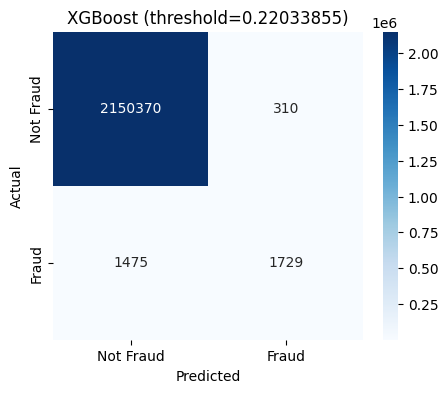

In [97]:
# Confusion matrix (use thresholded predictions)
cm = confusion_matrix(y_test, y_proba)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f'XGBoost (threshold={THRESHOLD})')
plt.show()

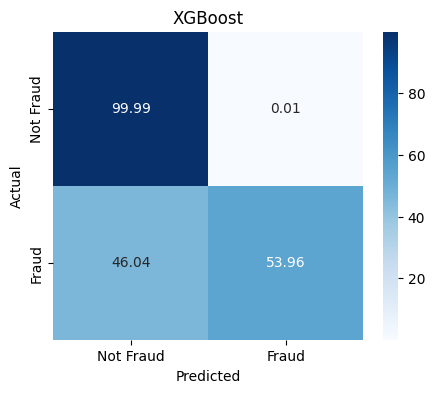

In [98]:
row_sums = cm.sum(axis=1, keepdims=True)
cm_pct_rows = cm / row_sums * 100
 
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_pct_rows, annot=True, fmt=".2f", cmap="Blues", cbar=True,
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"],
            ax=ax)
ax.set_title("XGBoost")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.show()
 

In [93]:
'''# Confusion matrix values from your model
true_negatives = cm[0,0]
false_positives = cm[0,1]
false_negatives = cm[1,0]
true_positives = cm[1,1]

# Business assumptions
avg_fraud_value = 500      # average loss per fraud case / R500 
avg_customer_inconvenience = 50  # cost per false positive / R50 

# Business impact calculations
fraud_prevented = true_positives * avg_fraud_value
fraud_missed = false_negatives * avg_fraud_value
customer_inconvenience_cost = false_positives * avg_customer_inconvenience

net_savings = fraud_prevented - fraud_missed - customer_inconvenience_cost
total_loss = fraud_prevented - net_savings

# Print results
print(f"Fraud prevented: R {fraud_prevented:,}")
print(f"Fraud missed: R {fraud_missed:,}")
print(f"Customer inconvenience cost: R {customer_inconvenience_cost:,}")
print(f"Total loss: R {total_loss:,}")
print(f"Net business impact: R {net_savings:,}")'''

'# Confusion matrix values from your model\ntrue_negatives = cm[0,0]\nfalse_positives = cm[0,1]\nfalse_negatives = cm[1,0]\ntrue_positives = cm[1,1]\n\n# Business assumptions\navg_fraud_value = 500      # average loss per fraud case / R500 \navg_customer_inconvenience = 50  # cost per false positive / R50 \n\n# Business impact calculations\nfraud_prevented = true_positives * avg_fraud_value\nfraud_missed = false_negatives * avg_fraud_value\ncustomer_inconvenience_cost = false_positives * avg_customer_inconvenience\n\nnet_savings = fraud_prevented - fraud_missed - customer_inconvenience_cost\ntotal_loss = fraud_prevented - net_savings\n\n# Print results\nprint(f"Fraud prevented: R {fraud_prevented:,}")\nprint(f"Fraud missed: R {fraud_missed:,}")\nprint(f"Customer inconvenience cost: R {customer_inconvenience_cost:,}")\nprint(f"Total loss: R {total_loss:,}")\nprint(f"Net business impact: R {net_savings:,}")'

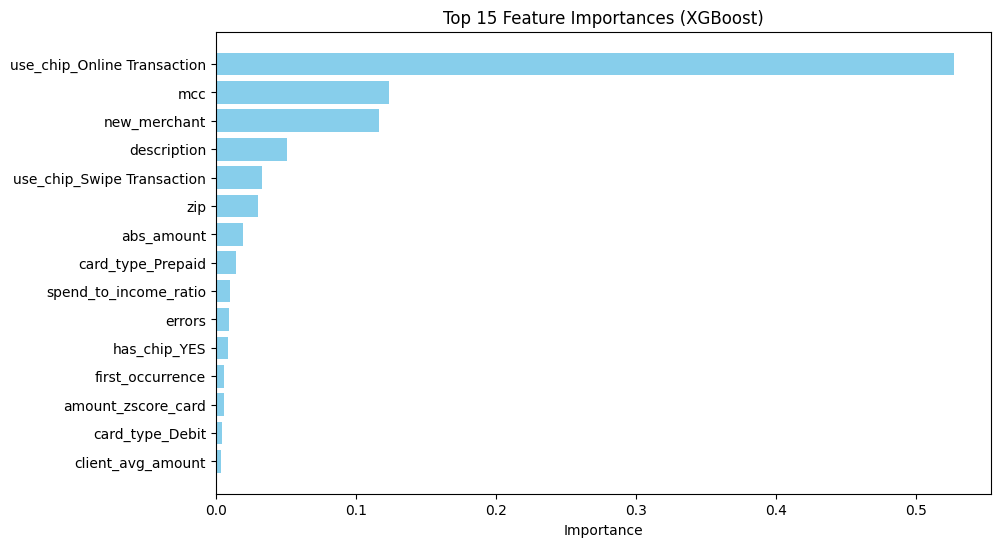

In [99]:
# feature importance
feature_importance = (
    pd.DataFrame({
        'feature': X.columns,
        'importance': xgb_model.feature_importances_
    })
    .sort_values('importance', ascending=False)
)

# Plot top 21 features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'], color='skyblue')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()

In [100]:
print("\nAll Features (Importantance-DSC):")
display(feature_importance)


All Features (Importantance-DSC):


,feature,importance
16,use_chip_Online Transaction,0.527252
7,mcc,0.123993
5,new_merchant,0.116597
3,description,0.050759
17,use_chip_Swipe Transaction,0.033273
6,zip,0.029946
1,abs_amount,0.019465
22,card_type_Prepaid,0.014055
4,spend_to_income_ratio,0.009808
8,errors,0.009097


In [102]:
feat_imp = ['new_merchant','use_chip_Online Transaction',
            'description', 'mcc',
            'use_chip_Swipe Transaction','card_type_Prepaid',
            'abs_amount','has_chip_YES','errors']

X = X[feat_imp]

X.shape

(8615533, 9)

In [103]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import numpy as np

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    scoring="average_precision",  # PR-AUC
    cv=cv,
    n_jobs=-1
)

print("CV PR-AUC:", np.mean(scores))

CV PR-AUC: 0.5449757705747248


In [104]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


In [105]:
from sklearn.metrics import average_precision_score

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
print("Test PR-AUC:", average_precision_score(y_test, y_pred_proba))

Test PR-AUC: 0.5913025454601144


In [112]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Compute F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the threshold with max F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("F1 at best threshold:", f1_scores[best_idx])

Best threshold: 0.97641194
F1 at best threshold: 0.6022129512062399


In [119]:
THRESHOLD = 0.07
y_proba = (y_pred >= THRESHOLD).astype(int)

In [120]:
print("\nClassification Report:")
print(classification_report(y_test, y_proba, target_names=["Non Fraud", "Fraud"]))


Classification Report:
              precision    recall  f1-score   support

   Non Fraud       1.00      1.00      1.00   2150680
       Fraud       0.58      0.63      0.60      3204

    accuracy                           1.00   2153884
   macro avg       0.79      0.81      0.80   2153884
weighted avg       1.00      1.00      1.00   2153884



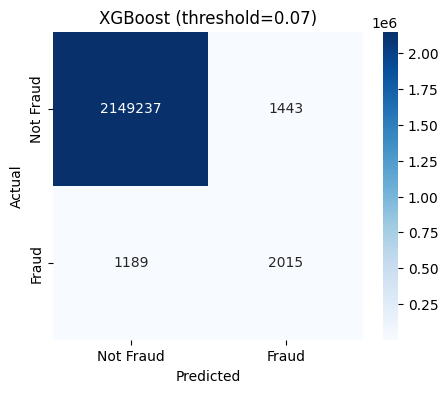

In [121]:
# Confusion matrix (use thresholded predictions)
cm = confusion_matrix(y_test, y_proba)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f'XGBoost (threshold={THRESHOLD})')
plt.show()

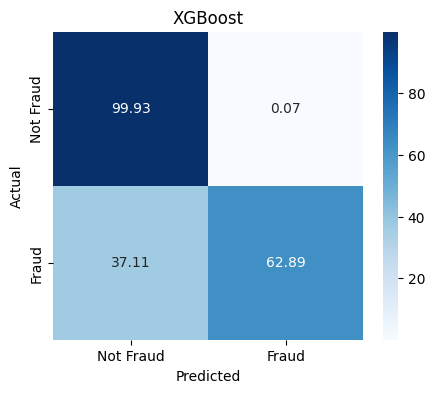

In [122]:
row_sums = cm.sum(axis=1, keepdims=True)
cm_pct_rows = cm / row_sums * 100
 
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_pct_rows, annot=True, fmt=".2f", cmap="Blues", cbar=True,
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"],
            ax=ax)
ax.set_title("XGBoost")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.show()


In [123]:
# Precision-recall curve (use probabilities)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# PR-AUC
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

# ROC AUC (use probabilities)
print("ROC AUC:", roc_auc_score(y_test, y_pred))

PR-AUC: 0.663974391875488
ROC AUC: 0.9840518659841685


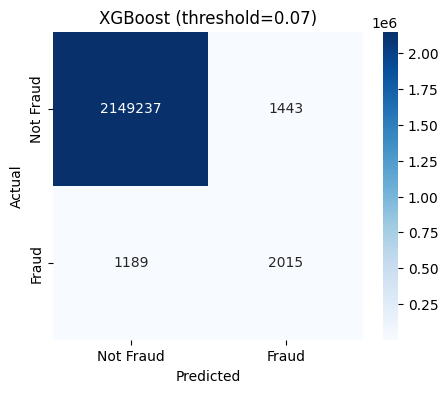

In [124]:
# Confusion matrix (use thresholded predictions)
cm = confusion_matrix(y_test, y_proba)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f'XGBoost (threshold={THRESHOLD})')
plt.show()